# **Modelo Predictor de Precios de Vuelos**
Este notebook realiza el análisis exploratorio, la limpieza y el preprocesamiento del dataset de vuelos de la India, con el objetivo de construir después un modelo de Machine Learning que prediga el precio de un tiquete a partir de las características del vuelo.

### **Fase 1 - EDA, limpieza y preprocesamiento**

### Problema de negocio y variable objetivo

El dataset recoge las tarifas de vuelos nacionales en India entre las seis ciudades con mayor tráfico aéreo (Delhi, Mumbai, Bangalore, Kolkata, Hyderabad y Chennai), tomadas de la plataforma de reservas *EaseMyTrip* durante un periodo de 50 días.

El problema de negocio es el siguiente: **el precio de un tiquete aéreo no es fijo**. Cambia según la aerolínea, la ruta, la hora de salida, el número de escalas, la clase y, sobre todo, según cuántos días falten para el vuelo. Para un pasajero eso significa que no sabe si el precio que está viendo es bueno o si le conviene esperar; para una agencia de viajes significa que no puede anticiparle al cliente cuánto le costará un viaje que todavía no ha reservado.

Un modelo que estime el precio a partir de las características del vuelo sirve para dos cosas concretas: recomendarle al usuario el mejor momento para comprar, y detectar tarifas que están por encima de lo que deberían costar según el mercado.

**Variable objetivo:** `price`, el precio del tiquete en rupias indias (INR). Como es una variable numérica continua, esto es un **problema de regresión**, a diferencia del notebook de tiroides donde predecíamos una categoría.

#### Importación de librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

#### Cargar dataset

In [2]:
df_flights = pd.read_csv('data/Clean_Dataset.csv')

#### Exploración inicial

In [3]:
df_flights.shape

(300153, 12)

In [4]:
df_flights.head(5)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
df_flights.tail(5)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [6]:
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


El dataset tiene **300.153 registros y 12 columnas**, y ninguna presenta valores nulos. Es un volumen muy distinto al del notebook de clasificación (364 pacientes), y eso cambia varias decisiones más adelante: aquí sí podemos darnos el lujo de eliminar registros si hiciera falta, y en cambio hay que cuidar el costo computacional de los modelos.

De las 12 columnas, 3 son numéricas (`duration`, `days_left` y `price`) y 8 son categóricas. La columna restante, `Unnamed: 0`, es el índice con el que se exportó el CSV: va de 0 a 300.152 y no representa ninguna característica del vuelo. Se elimina porque, si se dejara, el modelo podría tomarla como una variable predictora cuando en realidad es un consecutivo sin significado.

In [7]:
# La primera columna es el índice con el que se exportó el CSV, no aporta información del vuelo
df_flights = df_flights.drop(columns=['Unnamed: 0'])

df_flights.shape

(300153, 11)

#### Diccionario de datos

| # | Columna | Tipo esperado | Significado |
|---|---------|---------------|-------------|
| 1 | **airline** | Categórica (nominal) | Aerolínea que opera el vuelo. 6 valores posibles |
| 2 | **flight** | Categórica (identificador) | Código del vuelo, con el prefijo de la aerolínea y el número (ej. `SG-8709`) |
| 3 | **source_city** | Categórica (nominal) | Ciudad de origen del vuelo |
| 4 | **departure_time** | Categórica | Franja horaria de salida (Early_Morning, Morning, Afternoon, Evening, Night, Late_Night) |
| 5 | **stops** | Categórica (ordinal) | Número de escalas: `zero`, `one`, `two_or_more` |
| 6 | **arrival_time** | Categórica | Franja horaria de llegada, con las mismas 6 categorías que la salida |
| 7 | **destination_city** | Categórica (nominal) | Ciudad de destino |
| 8 | **class** | Categórica (ordinal) | Clase del tiquete: `Economy` o `Business` |
| 9 | **duration** | Numérica (float) | Duración total del vuelo en horas |
| 10 | **days_left** | Numérica (int) | Días entre la fecha de consulta y la fecha del vuelo |
| 11 | **price** | Numérica (int) | **Variable objetivo.** Precio del tiquete en rupias indias |

Vale la pena aclarar que `duration` y `days_left` son numéricas de verdad (magnitudes medibles), mientras que `stops` viene escrita como texto aunque represente un conteo. Esa diferencia es la que después justifica tratarla como ordinal y no como nominal.

#### Análisis descriptivo de las variables numéricas

In [8]:
df_flights.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


Tres cosas llaman la atención en estos estadísticos:

**1. La media del precio (20.889) está muy por encima de la mediana (7.425).** Casi tres veces. Cuando la media se despega tanto de la mediana es porque la distribución no es simétrica: hay un grupo de tiquetes muy caros que empuja el promedio hacia arriba mientras la mitad de los vuelos cuesta menos de 7.425 rupias. En términos del negocio, esto significa que hablar del "precio promedio de un vuelo" es engañoso; el pasajero típico paga bastante menos que ese promedio.

**2. La desviación estándar del precio (22.697) es mayor que la propia mediana.** Es una dispersión enorme: los precios van desde 1.105 hasta 123.071 rupias, una diferencia de más de 100 veces entre el tiquete más barato y el más caro. Esto ya anticipa que un solo modelo va a tener que explicar dos realidades muy distintas, y la sospecha inmediata es que la clase (Economy vs Business) sea la responsable.

**3. `days_left` va de 1 a 49 con media 26 y mediana 26.** Aquí sí hay simetría, y no es casualidad: los datos se recolectaron durante 50 días consultando precios todos los días, así que la anticipación está repartida de forma prácticamente uniforme. Es una buena noticia metodológica, porque significa que tenemos observaciones suficientes en todos los niveles de anticipación y no vamos a tener que extrapolar.

Sobre `duration`, la media (12.22 horas) y la mediana (11.25) están relativamente cerca, aunque el máximo de 49.83 horas para un vuelo doméstico es llamativo. Eso se revisa en el análisis de outliers.

In [9]:
# Se define la lista de categóricas de forma explícita para no depender del dtype
categoricas = ['airline', 'flight', 'source_city', 'departure_time',
               'stops', 'arrival_time', 'destination_city', 'class']

df_flights[categoricas].describe()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


De las 8 columnas categóricas, 7 tienen cardinalidad baja (entre 2 y 6 categorías) y una se sale completamente de ese rango: **`flight` tiene 1.561 valores distintos**. Esa diferencia va a ser determinante en el punto 9, porque una variable con esa cardinalidad no se puede codificar igual que una de 6 categorías.

Los valores más frecuentes también dicen algo del mercado: Vistara opera 127.859 de los 300.153 registros (42.6%), y la mayoría de los vuelos son de clase Economy (206.666, el 68.9%). Delhi es la ciudad de origen más frecuente.

#### Tratamiento de duplicados y nulos

In [10]:
df_flights.duplicated().sum()

np.int64(0)

No hay registros duplicados. Esto tiene sentido si se piensa en cómo se construyó el dataset: cada fila es la consulta del precio de un vuelo específico en un día específico, y como `days_left` cambia todos los días, dos filas del mismo vuelo nunca terminan siendo idénticas.

Es un contraste con el dataset de tiroides, donde sí hubo que eliminar 19 duplicados. Allá cada fila era un paciente y dos pacientes podían coincidir en las 17 características; aquí la combinación de vuelo, anticipación y precio hace que cada registro sea único.

In [11]:
# Conteo de nulos por columna y su porcentaje sobre el total de registros
nulos = pd.DataFrame({
    'Nulos': df_flights.isnull().sum(),
    '% Nulos': (df_flights.isnull().sum() / len(df_flights) * 100).round(2)
})

nulos

,Nulos,% Nulos
airline,0,0.0
flight,0,0.0
source_city,0,0.0
departure_time,0,0.0
stops,0,0.0
arrival_time,0,0.0
destination_city,0,0.0
class,0,0.0
duration,0,0.0
days_left,0,0.0


Las 11 columnas reportan 0 nulos (0.00%), así que no hay que imputar ni eliminar nada por este motivo. El dataset ya viene depurado por el autor en Kaggle, que es justamente lo que distingue al archivo `Clean_Dataset.csv` de los crudos `economy.csv` y `business.csv`, donde la duración viene como texto (`"02h 10m"`) y la fecha sin parsear.

Aun así conviene dejar definida la estrategia que se programará en el Pipeline, porque un dataset limpio hoy no garantiza que la fuente lo siga estando mañana:

- Para las **numéricas** (`duration`, `days_left`) la imputación adecuada es la **mediana**. Ya vimos que el precio tiene una distribución muy sesgada, y aunque `duration` lo está menos, la mediana sigue siendo la opción segura porque no se mueve con los vuelos de 40 horas.
- Para las **categóricas** la única opción sensata es la **moda**. No existe un punto medio entre `Delhi` y `Mumbai`, así que se asigna la categoría más frecuente.

Eliminar filas con nulos sería viable aquí, a diferencia del dataset de tiroides: con 300 mil registros, perder unos cuantos cientos no tendría ningún impacto. Pero como estrategia general es peor, porque en producción no se puede simplemente "no predecir" un vuelo al que le falta un dato.

#### Inconsistencias de formato

In [12]:
# Valores únicos de cada columna categórica
resumen_categoricas = pd.DataFrame({
    'Únicos': [df_flights[col].nunique() for col in categoricas],
    'Valores': [df_flights[col].unique()[:8].tolist() for col in categoricas]
}, index=categoricas)

resumen_categoricas

,Únicos,Valores
airline,6,"[SpiceJet, AirAsia, Vistara, GO_FIRST, Indigo,..."
flight,1561,"[SG-8709, SG-8157, I5-764, UK-995, UK-963, UK-..."
source_city,6,"[Delhi, Mumbai, Bangalore, Kolkata, Hyderabad,..."
departure_time,6,"[Evening, Early_Morning, Morning, Afternoon, N..."
stops,3,"[zero, one, two_or_more]"
arrival_time,6,"[Night, Morning, Early_Morning, Afternoon, Eve..."
destination_city,6,"[Mumbai, Bangalore, Kolkata, Hyderabad, Chenna..."
class,2,"[Economy, Business]"


In [13]:
# Revisión de espacios sobrantes y de etiquetas equivalentes escritas de forma distinta
for col in categoricas:
    valores = df_flights[col].astype(str)
    con_espacios = (valores != valores.str.strip()).sum()
    equivalentes = valores.nunique() - valores.str.strip().str.lower().nunique()

    print(f"{col:20s} | espacios sobrantes: {con_espacios:3d} | etiquetas equivalentes: {equivalentes}")

airline              | espacios sobrantes:   0 | etiquetas equivalentes: 0
flight               | espacios sobrantes:   0 | etiquetas equivalentes: 0
source_city          | espacios sobrantes:   0 | etiquetas equivalentes: 0
departure_time       | espacios sobrantes:   0 | etiquetas equivalentes: 0
stops                | espacios sobrantes:   0 | etiquetas equivalentes: 0
arrival_time         | espacios sobrantes:   0 | etiquetas equivalentes: 0
destination_city     | espacios sobrantes:   0 | etiquetas equivalentes: 0
class                | espacios sobrantes:   0 | etiquetas equivalentes: 0


In [14]:
# El código de vuelo trae un prefijo de aerolínea. Se revisa si concuerda con la columna airline
prefijos = df_flights['flight'].str.split('-').str[0]

pd.crosstab(prefijos, df_flights['airline'])

airline,AirAsia,Air_India,GO_FIRST,Indigo,SpiceJet,Vistara
flight,,,,,,
6E,0,0,0,43120,0,0
AI,0,80892,0,0,0,0
G8,0,0,23173,0,0,0
I5,16098,0,0,0,0,0
SG,0,0,0,0,9011,0
UK,0,0,0,0,0,127859


No hay inconsistencias de formato: ninguna columna tiene espacios sobrantes y el número de valores únicos no cambia al pasar todo a minúsculas y recortar espacios, lo que descarta que existan etiquetas equivalentes escritas de dos maneras (tipo `Delhi` y `delhi`). Las categorías vienen escritas de forma uniforme, con guion bajo como separador (`Early_Morning`, `two_or_more`, `Air_India`).

Lo que sí aparece al cruzar el prefijo del código de vuelo contra la aerolínea es una **redundancia perfecta**: cada prefijo pertenece a una sola aerolínea (`UK` es siempre Vistara, `AI` siempre Air_India, `6E` siempre Indigo, y así con las seis). O sea que la columna `flight` contiene la información de `airline` y, además, el número específico del vuelo.

Esto no es un error que haya que corregir, pero sí es un hallazgo importante para el punto 9: la mitad de la información de `flight` ya está en otra columna, y la otra mitad es un identificador. Se retoma más adelante.

#### Outliers

In [15]:
# Paleta de colores personalizada (la misma del notebook de clasificación)
color_palette = ['#440154', '#3B528B', '#21918C', '#5EC962', '#FDE725']
sns.set_palette(color_palette)

In [16]:
# Criterio IQR sobre las dos numéricas relevantes
for col in ['price', 'duration']:
    q1 = df_flights[col].quantile(0.25)
    q3 = df_flights[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_flights[(df_flights[col] < lower_bound) | (df_flights[col] > upper_bound)]

    print(f"{col}")
    print(f"  Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
    print(f"  Límites: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers: {outliers.shape[0]} ({outliers.shape[0] / len(df_flights) * 100:.2f}%)\n")

price
  Q1: 4783.00 | Q3: 42521.00 | IQR: 37738.00
  Límites: [-51824.00, 99128.00]
  Outliers: 123 (0.04%)

duration
  Q1: 6.83 | Q3: 16.17 | IQR: 9.34
  Límites: [-7.18, 30.18]
  Outliers: 2110 (0.70%)



El resultado del IQR global sobre `price` es sospechoso: el límite inferior da **-51.824 rupias**, un precio negativo que no tiene sentido, y con esos límites apenas 123 registros (0.04%) quedan marcados como outliers. Un criterio que no detecta prácticamente nada en una variable que va de 1.105 a 123.071 está fallando.

La razón es que el IQR asume una distribución con un solo centro, y aquí hay dos: los tiquetes de Economy y los de Business son dos poblaciones de precios completamente distintas. Al mezclarlas, el rango intercuartílico se infla artificialmente (Q1 = 4.783 cae en Economy y Q3 = 42.521 cae en Business), y unos límites tan anchos no marcan a nadie.

Es el mismo problema que enfrentamos en el notebook de tiroides con la edad, y la solución es la misma: aplicar el criterio **dentro de cada grupo**.

In [17]:
# IQR del precio dentro de cada clase
for clase in df_flights['class'].unique():
    precios = df_flights.loc[df_flights['class'] == clase, 'price']

    q1_clase = precios.quantile(0.25)
    q3_clase = precios.quantile(0.75)
    iqr_clase = q3_clase - q1_clase

    lower_clase = q1_clase - 1.5 * iqr_clase
    upper_clase = q3_clase + 1.5 * iqr_clase

    outliers_clase = precios[(precios < lower_clase) | (precios > upper_clase)]

    print(f"class = {clase}  (n = {precios.shape[0]})")
    print(f"  Q1: {q1_clase:.0f} | Q3: {q3_clase:.0f} | IQR: {iqr_clase:.0f}")
    print(f"  Límites: [{lower_clase:.0f}, {upper_clase:.0f}]")
    print(f"  Outliers: {outliers_clase.shape[0]} ({outliers_clase.shape[0] / len(precios) * 100:.2f}%)")
    print(f"  Precio mínimo: {precios.min()} | máximo: {precios.max()}\n")

class = Economy  (n = 206666)
  Q1: 4173 | Q3: 7746 | IQR: 3573
  Límites: [-1186, 13106]
  Outliers: 13749 (6.65%)
  Precio mínimo: 1105 | máximo: 42349

class = Business  (n = 93487)
  Q1: 45185 | Q3: 60396 | IQR: 15211
  Límites: [22368, 83212]
  Outliers: 3650 (3.90%)
  Precio mínimo: 12000 | máximo: 123071



In [18]:
# IQR de la duración dentro de cada nivel de escalas
for escalas in ['zero', 'one', 'two_or_more']:
    duraciones = df_flights.loc[df_flights['stops'] == escalas, 'duration']

    q1_esc = duraciones.quantile(0.25)
    q3_esc = duraciones.quantile(0.75)
    iqr_esc = q3_esc - q1_esc

    lower_esc = q1_esc - 1.5 * iqr_esc
    upper_esc = q3_esc + 1.5 * iqr_esc

    outliers_esc = duraciones[(duraciones < lower_esc) | (duraciones > upper_esc)]

    print(f"stops = {escalas}  (n = {duraciones.shape[0]})")
    print(f"  Mediana: {duraciones.median():.2f} h | Límites: [{lower_esc:.2f}, {upper_esc:.2f}]")
    print(f"  Outliers: {outliers_esc.shape[0]} ({outliers_esc.shape[0] / len(duraciones) * 100:.2f}%)")
    print(f"  Duración máxima: {duraciones.max():.2f} h\n")

stops = zero  (n = 36004)
  Mediana: 2.25 h | Límites: [0.93, 3.57]
  Outliers: 140 (0.39%)
  Duración máxima: 3.58 h

stops = one  (n = 250863)
  Mediana: 12.25 h | Límites: [-4.88, 30.12]
  Outliers: 1296 (0.52%)
  Duración máxima: 49.83 h

stops = two_or_more  (n = 13286)
  Mediana: 12.67 h | Límites: [-3.62, 32.70]
  Outliers: 424 (3.19%)
  Duración máxima: 49.83 h



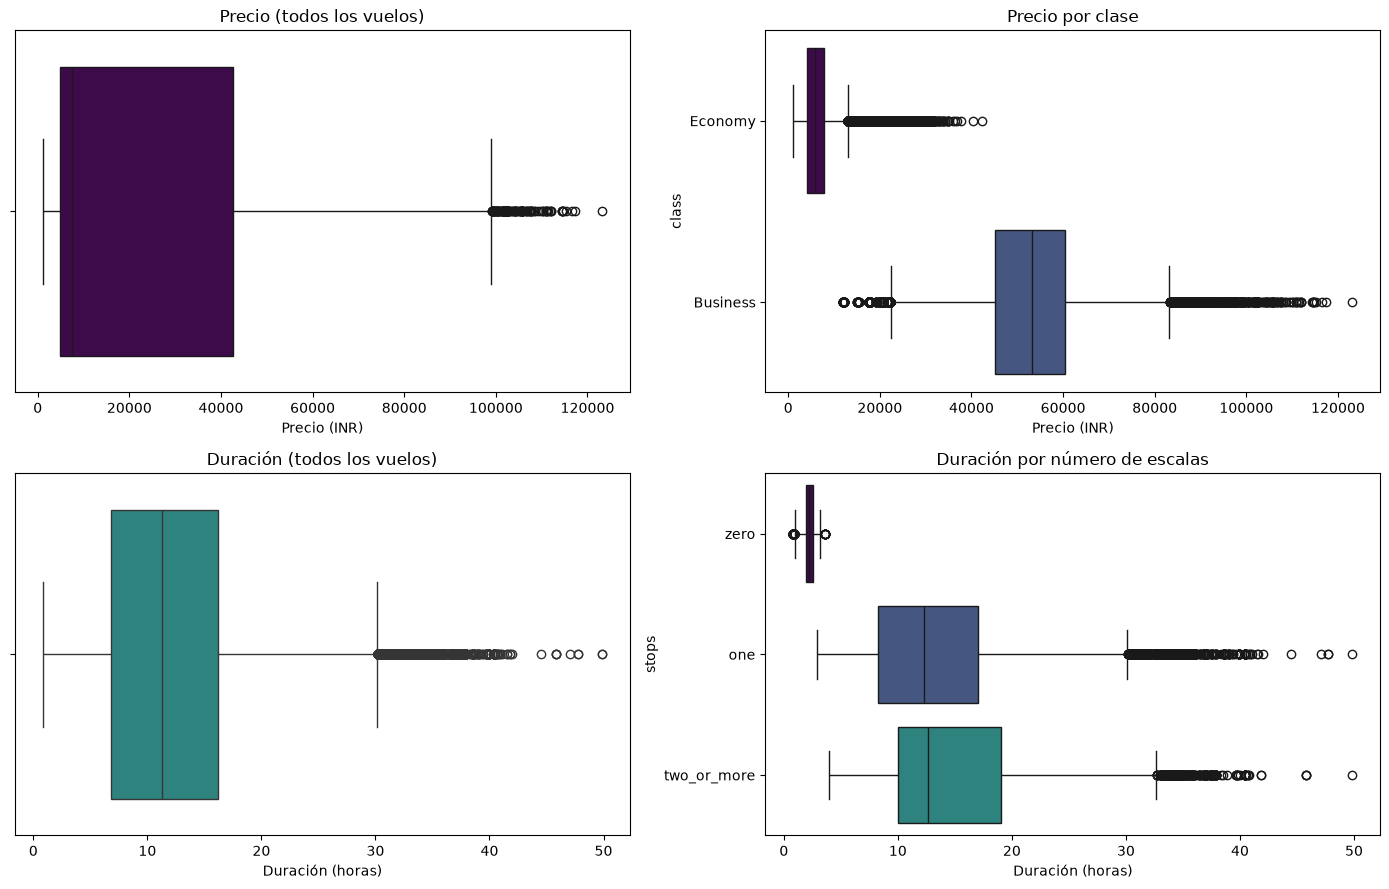

In [19]:
# Boxplots de las dos variables numéricas, global y por grupo
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(x=df_flights['price'], ax=axes[0, 0], color=color_palette[0])
axes[0, 0].set_title('Precio (todos los vuelos)')
axes[0, 0].set_xlabel('Precio (INR)')

sns.boxplot(data=df_flights, x='price', y='class', hue='class',
            palette=color_palette[:2], legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Precio por clase')
axes[0, 1].set_xlabel('Precio (INR)')

sns.boxplot(x=df_flights['duration'], ax=axes[1, 0], color=color_palette[2])
axes[1, 0].set_title('Duración (todos los vuelos)')
axes[1, 0].set_xlabel('Duración (horas)')

sns.boxplot(data=df_flights, x='duration', y='stops', hue='stops',
            order=['zero', 'one', 'two_or_more'],
            palette=color_palette[:3], legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Duración por número de escalas')
axes[1, 1].set_xlabel('Duración (horas)')

plt.tight_layout()
plt.show()

Al calcular el IQR dentro de cada grupo el panorama cambia por completo:

| Variable | Grupo | Outliers | % del grupo |
|---|---|---|---|
| price | Economy | 13.749 | 6.65% |
| price | Business | 3.650 | 3.90% |
| duration | zero (directos) | 140 | 0.39% |
| duration | one | 1.296 | 0.52% |
| duration | two_or_more | 424 | 3.19% |

En lugar de los 123 que detectaba el criterio global, aparecen **17.399 precios atípicos**. Los boxplots lo muestran con claridad: el de precio global tiene una caja tan ancha que no dice nada, mientras que separado por clase se ven dos distribuciones bien definidas, cada una con su propia cola de valores altos.

El caso de la duración es interesante por otro motivo. Los vuelos directos tienen una mediana de 2.25 horas y un máximo de 3.58, lo cual es perfectamente coherente con vuelos domésticos en India; de sus 140 outliers, 130 son vuelos de menos de 56 minutos (rutas cortas como Delhi-Bangalore) y solo 10 superan el límite superior. En cambio, el máximo de 49.83 horas del dataset corresponde a vuelos con escala, y hay 48 vuelos que pasan de 40 horas. No son errores de captura sino itinerarios con conexiones de un día entero, y de hecho 45 de esos 48 vuelos son de clase Economy con un precio mediano de 11.145 rupias, más del doble de la mediana de su propia clase. Que los vuelos más largos sean también los más caros es contraintuitivo y se revisa en las gráficas del EDA.

**Decisión: no se eliminan, se documentan.** Las razones:

1. **Tienen sentido de negocio.** Un tiquete de Economy de 42.349 rupias es exactamente el fenómeno que queremos modelar: alguien comprando a última hora en temporada alta. Si eliminamos esos casos, el modelo aprende a predecir bien los precios normales y falla justo en los que más le importan al negocio, que son los picos.
2. **Son demasiados como para ignorarlos.** 17.399 registros son el 5.8% del dataset. Un porcentaje así no es un puñado de errores de digitación, es una característica estructural de los precios aéreos: la distribución tiene cola larga por naturaleza.
3. **El precio es la variable objetivo, no una predictora.** Recortar outliers en el target es directamente cambiar el problema: estaríamos entrenando un modelo que nunca ha visto un tiquete caro y que por lo tanto jamás va a predecir uno.

La recomendación para quien tome la decisión es no depurar, pero sí reportar las métricas separadas por clase cuando se evalúe el modelo. Un MAE global va a estar dominado por los errores en Business, que son de un orden de magnitud mayor, y podría esconder que el modelo funciona mal en Economy, que es donde está el 69% de los pasajeros.

#### Gráficos EDA

Las gráficas se organizan en cuatro bloques temáticos, cada uno con su interpretación y su recomendación: la composición del mercado, la distribución del precio, el efecto de la anticipación de compra, y el efecto de la ruta y las escalas.

##### Composición del mercado: aerolíneas y clases

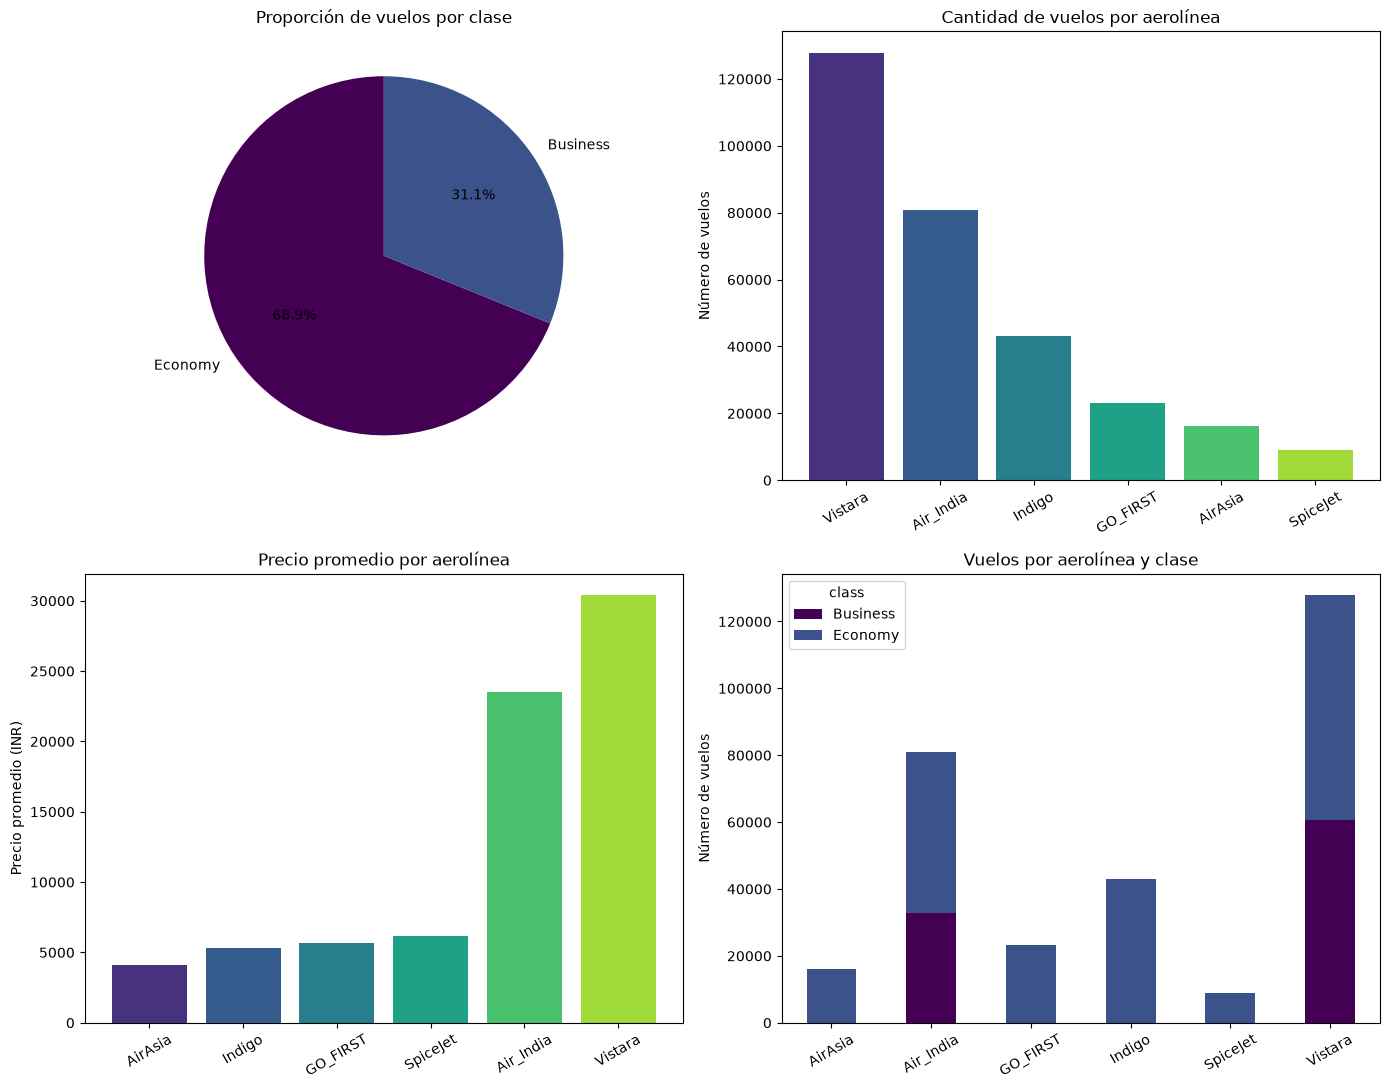

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Proporción de vuelos por clase
class_counts = df_flights['class'].value_counts()
axes[0, 0].pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción de vuelos por clase')

# 2. Cantidad de vuelos por aerolínea
airline_counts = df_flights['airline'].value_counts()
axes[0, 1].bar(airline_counts.index, airline_counts.values,
               color=sns.color_palette('viridis', len(airline_counts)))
axes[0, 1].set_title('Cantidad de vuelos por aerolínea')
axes[0, 1].set_ylabel('Número de vuelos')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Precio promedio por aerolínea
precio_airline = df_flights.groupby('airline')['price'].mean().sort_values()
axes[1, 0].bar(precio_airline.index, precio_airline.values,
               color=sns.color_palette('viridis', len(precio_airline)))
axes[1, 0].set_title('Precio promedio por aerolínea')
axes[1, 0].set_ylabel('Precio promedio (INR)')
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Qué aerolíneas venden cada clase
airline_class = pd.crosstab(df_flights['airline'], df_flights['class'])
airline_class.plot(kind='bar', stacked=True, ax=axes[1, 1], color=color_palette[:2])
axes[1, 1].set_title('Vuelos por aerolínea y clase')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Número de vuelos')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].legend(title='class')

plt.tight_layout()
plt.show()

A primera vista la tercera gráfica sugiere que Vistara (30.397 de precio promedio) y Air_India (23.507) son aerolíneas caras, mientras que AirAsia (4.091) es la barata. La diferencia es de más de siete veces, y sería fácil concluir que conviene recomendarle al cliente que vuele AirAsia.

La cuarta gráfica desmonta esa lectura: **solo Vistara y Air_India venden clase Business**. Las otras cuatro aerolíneas operan exclusivamente Economy. Entonces el promedio de Vistara no está diciendo que cobre más por el mismo servicio, sino que su catálogo incluye tiquetes ejecutivos de más de 50.000 rupias que arrastran la media hacia arriba. Comparar promedios entre aerolíneas sin separar por clase es comparar cosas distintas.

También conviene notar el desbalance de la muestra: Vistara y Air_India concentran el 69.5% de los registros, mientras SpiceJet aporta apenas el 3%. El modelo va a tener mucha menos evidencia para aprender el comportamiento de las aerolíneas pequeñas.

**Recomendación.** Cualquier comparación de precios entre aerolíneas que se le presente al área comercial tiene que hacerse dentro de la misma clase; de lo contrario el reporte induce a error. Y como `class` explica una parte tan grande de la variabilidad del precio, es la primera variable que hay que asegurarse de incluir en el modelo.

##### Distribución del precio

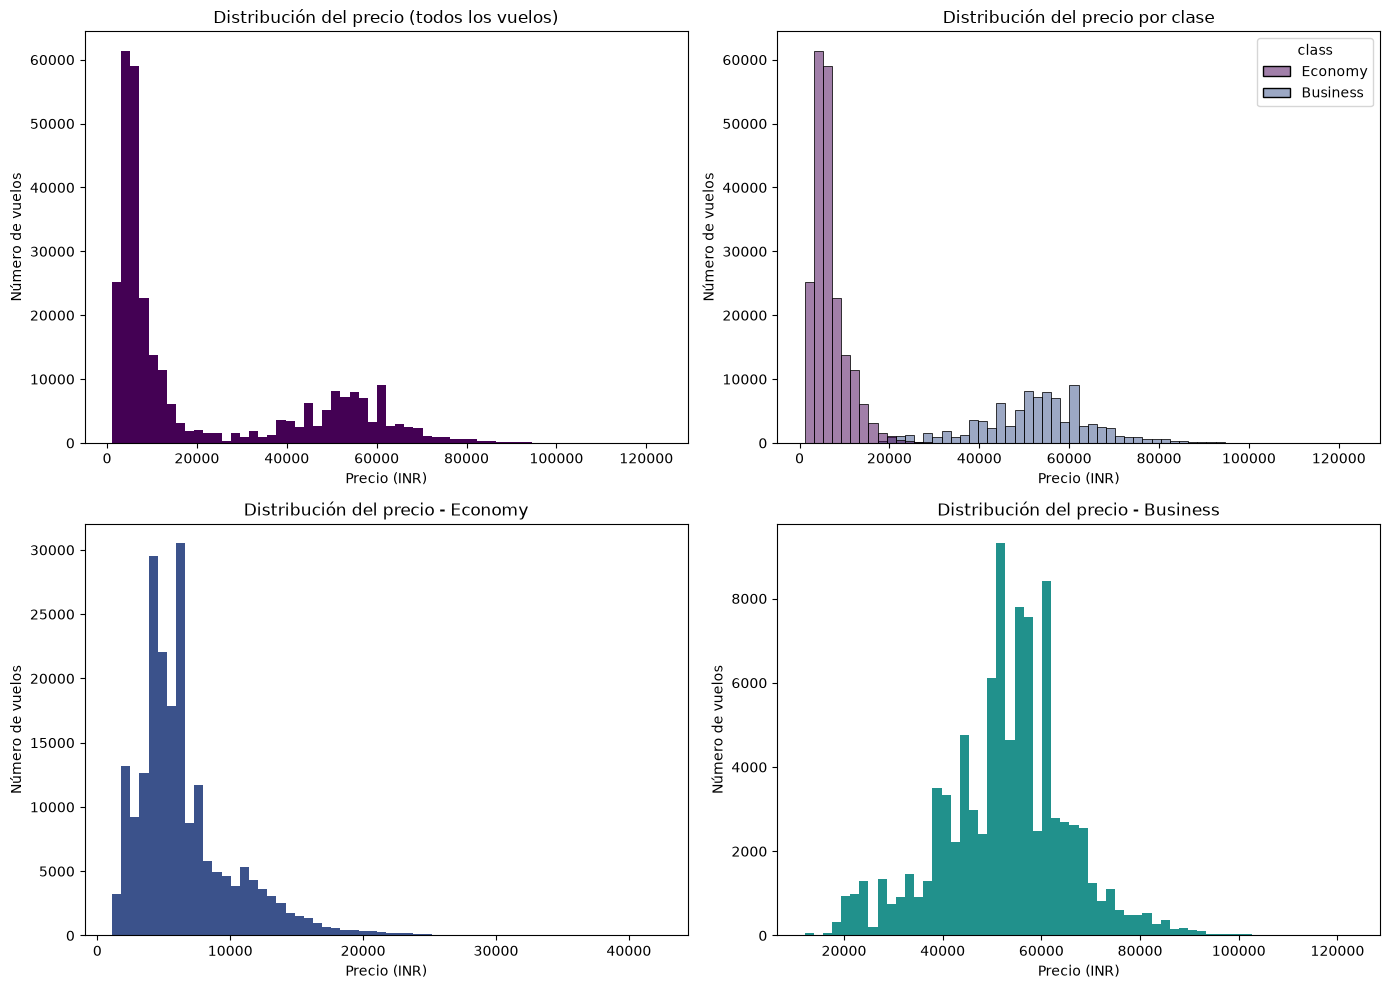

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histograma del precio (todos los vuelos)
axes[0, 0].hist(df_flights['price'], bins=60, color=color_palette[0])
axes[0, 0].set_title('Distribución del precio (todos los vuelos)')
axes[0, 0].set_xlabel('Precio (INR)')
axes[0, 0].set_ylabel('Número de vuelos')

# 2. Histograma separado por clase
sns.histplot(data=df_flights, x='price', hue='class', bins=60,
             palette=color_palette[:2], ax=axes[0, 1])
axes[0, 1].set_title('Distribución del precio por clase')
axes[0, 1].set_xlabel('Precio (INR)')
axes[0, 1].set_ylabel('Número de vuelos')

# 3. Solo Economy
axes[1, 0].hist(df_flights.loc[df_flights['class'] == 'Economy', 'price'],
                bins=60, color=color_palette[1])
axes[1, 0].set_title('Distribución del precio - Economy')
axes[1, 0].set_xlabel('Precio (INR)')
axes[1, 0].set_ylabel('Número de vuelos')

# 4. Solo Business
axes[1, 1].hist(df_flights.loc[df_flights['class'] == 'Business', 'price'],
                bins=60, color=color_palette[2])
axes[1, 1].set_title('Distribución del precio - Business')
axes[1, 1].set_xlabel('Precio (INR)')
axes[1, 1].set_ylabel('Número de vuelos')

plt.tight_layout()
plt.show()

El histograma general confirma lo que sospechábamos al ver que la media (20.889) triplicaba la mediana (7.425): la distribución del precio es **bimodal**. Hay una concentración enorme de vuelos baratos por debajo de las 10.000 rupias y un segundo grupo, mucho más disperso, alrededor de las 50.000. Entre los dos hay un valle casi vacío.

Al separar por clase queda claro de dónde sale cada moda. Economy se concentra entre 3.000 y 8.000 rupias con una cola hacia la derecha; Business se mueve entre 40.000 y 70.000, más simétrica pero mucho más ancha. Son dos mercados distintos que comparten una sola columna de precio.

Esto tiene consecuencias directas para el modelado. Un modelo lineal como la Regresión Lineal Múltiple va a tener dificultades para ajustar una distribución con dos centros: su predicción tenderá al promedio ponderado de ambos, que cae justo en el valle donde casi no hay vuelos. Los modelos basados en árboles, en cambio, pueden partir por `class` en el primer nodo y modelar cada rama por separado, así que se espera que les vaya bastante mejor. Es una hipótesis que conviene contrastar cuando se entrenen los modelos.

**Recomendación.** Además de reportar el MAE global, hay que reportarlo separado por clase. Un error de 3.000 rupias es catastrófico para un tiquete de Economy que cuesta 5.000, y es despreciable para uno de Business que cuesta 53.000. Un solo número promediado esconde esa diferencia.

##### Efecto de la anticipación de compra

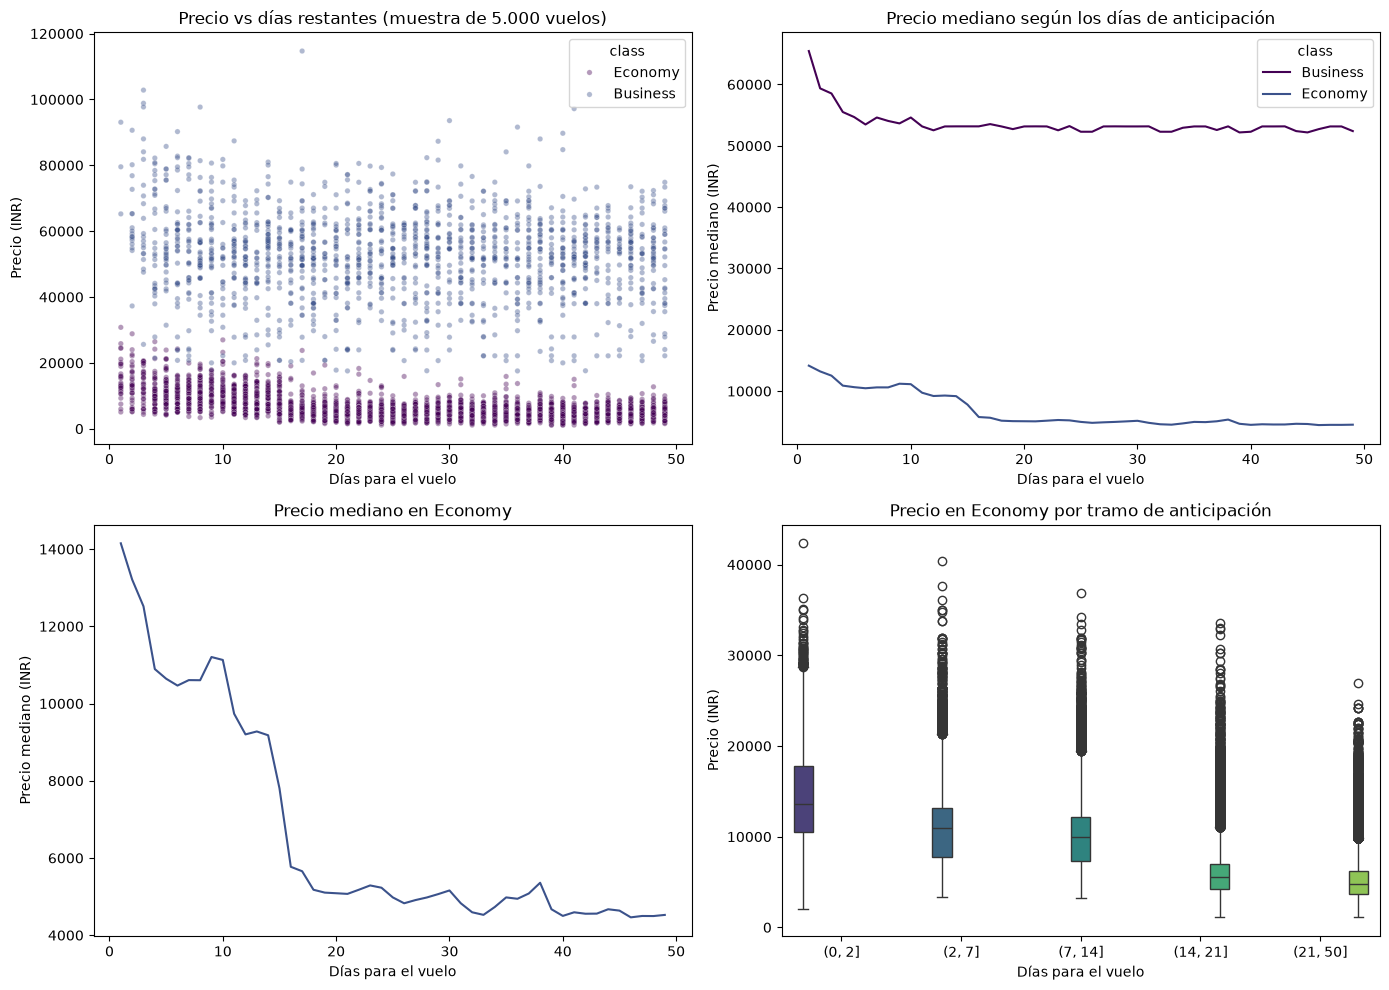

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Se usa una muestra para el scatter: con 300 mil puntos la gráfica se satura
muestra = df_flights.sample(n=5000, random_state=42)

# 1. Dispersión de precio contra días restantes
sns.scatterplot(data=muestra, x='days_left', y='price', hue='class',
                palette=color_palette[:2], alpha=0.4, s=15, ax=axes[0, 0])
axes[0, 0].set_title('Precio vs días restantes (muestra de 5.000 vuelos)')
axes[0, 0].set_xlabel('Días para el vuelo')
axes[0, 0].set_ylabel('Precio (INR)')

# 2. Precio mediano por día, separado por clase
mediana_dia = df_flights.groupby(['days_left', 'class'])['price'].median().unstack()
mediana_dia.plot(ax=axes[0, 1], color=color_palette[:2])
axes[0, 1].set_title('Precio mediano según los días de anticipación')
axes[0, 1].set_xlabel('Días para el vuelo')
axes[0, 1].set_ylabel('Precio mediano (INR)')
axes[0, 1].legend(title='class')

# 3. Lo mismo, pero solo Economy (para que se vea la escala)
economy = df_flights[df_flights['class'] == 'Economy']
economy.groupby('days_left')['price'].median().plot(ax=axes[1, 0], color=color_palette[1])
axes[1, 0].set_title('Precio mediano en Economy')
axes[1, 0].set_xlabel('Días para el vuelo')
axes[1, 0].set_ylabel('Precio mediano (INR)')

# 4. Distribución del precio de Economy por tramos de anticipación
tramos = pd.cut(economy['days_left'], [0, 2, 7, 14, 21, 50])
sns.boxplot(x=tramos, y=economy['price'], hue=tramos, legend=False,
            palette=sns.color_palette('viridis', 5), ax=axes[1, 1])
axes[1, 1].set_title('Precio en Economy por tramo de anticipación')
axes[1, 1].set_xlabel('Días para el vuelo')
axes[1, 1].set_ylabel('Precio (INR)')

plt.tight_layout()
plt.show()

Este es el hallazgo más importante del análisis, y también el más engañoso si uno se queda con el número resumido.

La correlación lineal entre `price` y `days_left` sobre el dataset completo es de apenas **-0.09**, un valor tan bajo que llevaría a descartar la variable. Pero al calcularla **dentro de Economy sube a -0.56**, y en Business se queda en -0.09. Es el mismo fenómeno que nos pasó en el notebook de tiroides con la variable Smoking: mezclar dos poblaciones con comportamientos distintos aplasta la correlación global.

Las gráficas explican por qué. En Economy el precio mediano se mantiene plano alrededor de las 4.800 rupias desde el día 49 hasta el día 18. Ahí pega un salto brusco (de 5.177 el día 18 a 7.804 el día 15) y a partir de ese punto sube de forma sostenida hasta las 14.150 rupias del último día. Visto por tramos, comprando con menos de 2 días de anticipación la mediana queda en **13.629 rupias, casi el triple** de las 4.796 que cuesta comprando con más de 21 días. En Business, en cambio, la línea es casi plana: pasa de 53.071 a 59.948, un incremento de apenas el 13%.

Tiene sentido desde el negocio: el pasajero de Economy suele planear con tiempo y es sensible al precio, así que la aerolínea puede castigar la compra de último minuto. El de Business viaja por trabajo, compra cuando le surge el viaje y paga lo que valga, así que no hay margen para subirle más.

**Recomendación.** `days_left` debe entrar al modelo sí o sí, pero hay que advertir que su efecto **no es lineal ni uniforme**: es plano durante 30 días y explota en los últimos 7. Una Regresión Lineal Múltiple, que solo puede ajustar una pendiente constante, va a subestimar los precios de última hora y sobreestimar los anticipados. Los árboles pueden capturar ese quiebre con un corte en `days_left < 7`, así que esta variable es una de las razones para esperar que los modelos de ensamble ganen. Para el producto, la recomendación al usuario es clara: en Economy, comprar con más de 21 días de anticipación ahorra alrededor del 65% del precio.

##### Ruta, escalas y duración

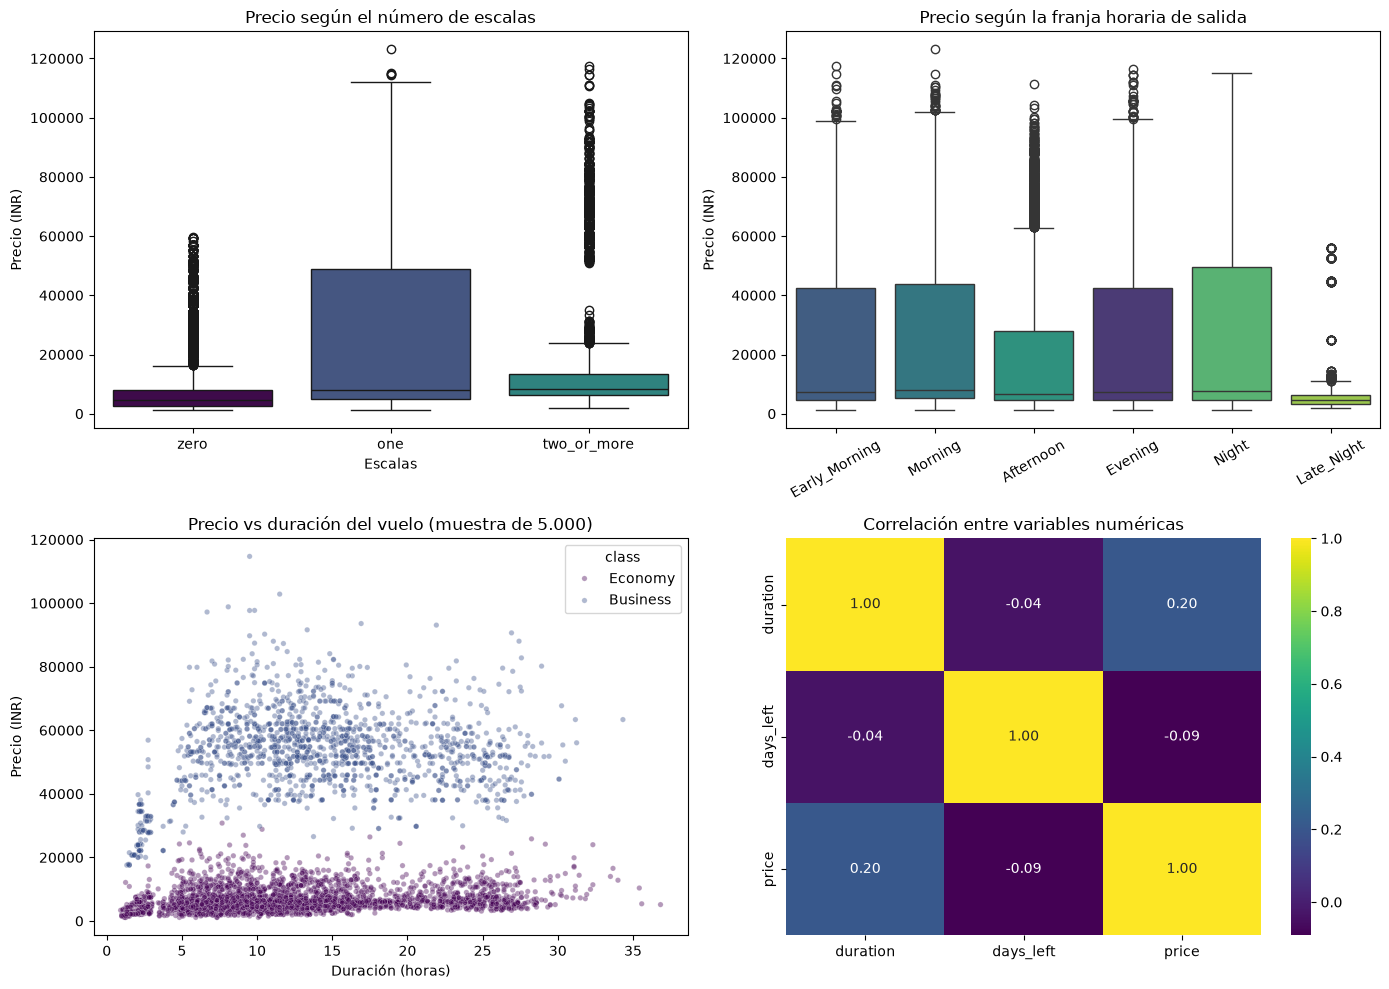

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Precio según el número de escalas
sns.boxplot(data=df_flights, x='stops', y='price', hue='stops',
            order=['zero', 'one', 'two_or_more'],
            palette=color_palette[:3], legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Precio según el número de escalas')
axes[0, 0].set_xlabel('Escalas')
axes[0, 0].set_ylabel('Precio (INR)')

# 2. Precio según la franja horaria de salida
orden_horario = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']
sns.boxplot(data=df_flights, x='departure_time', y='price', hue='departure_time',
            order=orden_horario, palette=sns.color_palette('viridis', 6),
            legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Precio según la franja horaria de salida')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Precio (INR)')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Duración contra precio
sns.scatterplot(data=muestra, x='duration', y='price', hue='class',
                palette=color_palette[:2], alpha=0.4, s=15, ax=axes[1, 0])
axes[1, 0].set_title('Precio vs duración del vuelo (muestra de 5.000)')
axes[1, 0].set_xlabel('Duración (horas)')
axes[1, 0].set_ylabel('Precio (INR)')

# 4. Correlación entre las variables numéricas
correlacion = df_flights[['duration', 'days_left', 'price']].corr()
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Correlación entre variables numéricas')

plt.tight_layout()
plt.show()

El boxplot de escalas muestra algo que a primera vista no cuadra: los vuelos con **una** escala tienen un precio promedio de 22.901 rupias, muy por encima de los directos (9.376) e incluso de los de dos o más escalas (14.113). Uno esperaría que más escalas signifique más barato. La explicación vuelve a ser la clase: el 83.6% del dataset son vuelos con una escala, y ahí está concentrada la mayor parte de la oferta Business. Si se miran las medianas en lugar de las medias, el orden se ordena bastante: 4.499 para los directos contra 7.959 y 8.307 para los que tienen escalas.

En la franja horaria, `Late_Night` aparece claramente como la más barata (9.295 de promedio contra 23.062 de `Night`). Es la franja con menos vuelos del dataset (1.306 registros), y son los horarios que nadie quiere.

El scatter de duración contra precio confirma lo que se veía en el análisis de outliers: la relación es positiva, no negativa. Vuelos más largos son más caros, con una correlación de +0.20 global y +0.29 dentro de Economy. La interpretación razonable es que la duración está actuando como un sustituto de la distancia de la ruta, y las rutas largas cuestan más; la nube de puntos también deja ver que los vuelos de menos de 3 horas son casi todos baratos, porque son los directos.

Los tres coeficientes del mapa de correlación son bajos (ninguno pasa de 0.21 en valor absoluto), y eso **no** significa que las variables no sirvan. Significa que las relaciones no son lineales y que las categóricas, que no aparecen en ese mapa, son las que realmente mandan aquí.

**Recomendación.** No descartar variables basándose en la matriz de correlación, que es la conclusión fácil y equivocada. La evidencia apunta a que `class` es el predictor dominante, seguido por `days_left` con un efecto fuertemente no lineal, y que la ruta y el horario aportan ajustes menores. Para el modelo, esto refuerza la expectativa de que los algoritmos basados en árboles superen a la regresión lineal.

#### Técnicas de codificación

Todos los algoritmos que se van a entrenar (Regresión Lineal Múltiple, KNN, Árbol de Decisión, Random Forest y Gradient Boosting) necesitan entradas numéricas, así que las 8 columnas categóricas hay que codificarlas. La decisión se toma variable por variable según tres criterios: si existe un orden natural, cuántas categorías tiene, y qué le hace ese encoding a los algoritmos que vamos a usar.

| Columna | ¿Orden natural? | Cardinalidad | Encoding elegido | Justificación |
|---------|-----------------|--------------|------------------|---------------|
| **airline** | No | 6 | One-Hot | Ninguna aerolínea es "mayor" que otra. Con Ordinal Encoding, KNN y la regresión lineal asumirían que Vistara (5) está cinco veces más lejos de AirAsia (0) que Indigo (1), que es un orden inventado. 6 columnas es un costo asumible |
| **flight** | No | **1.561** | **Se elimina** | Ver justificación abajo |
| **source_city** | No | 6 | One-Hot | Las ciudades no tienen orden. Además el modelo debe poder aprender que Delhi-Mumbai es distinto de Mumbai-Delhi, cosa imposible si se codifican como números en una escala |
| **destination_city** | No | 6 | One-Hot | Mismo razonamiento que la ciudad de origen |
| **departure_time** | Discutible | 6 | One-Hot | Ver justificación abajo |
| **arrival_time** | Discutible | 6 | One-Hot | Mismo caso que la hora de salida |
| **stops** | **Sí** | 3 | Ordinal (`zero` < `one` < `two_or_more`) | El orden es real y es un conteo. Codificarlo como 0, 1, 2 le entrega esa información al modelo en una sola columna en lugar de tres, y la distancia entre categorías sí tiene sentido |
| **class** | **Sí** | 2 | Ordinal (`Economy` < `Business`) | Con solo dos categorías, Ordinal y One-Hot producen la misma información, pero Ordinal lo hace con una columna en vez de dos. El orden además es real: Business es superior a Economy en servicio y en precio |

**Por qué se elimina `flight`.** Es la única decisión que implica botar una columna, así que hay que sustentarla bien. Tiene 1.561 categorías, y ninguna técnica funciona bien con eso: un One-Hot generaría 1.561 columnas nuevas sobre 300 mil filas, disparando el consumo de memoria y dejando la matriz casi vacía, lo que además le hace mucho daño a KNN porque en un espacio de esa dimensión todas las distancias se parecen. Un Ordinal Encoding sería peor todavía, porque inventaría que el vuelo `UK-995` es "mayor" que el `AI-773` sin ningún sustento.

Pero el argumento de fondo no es técnico sino de contenido: **la información de `flight` ya está en el dataset**. Como vimos al cruzar los prefijos contra `airline`, el prefijo determina la aerolínea de forma perfecta, y lo único que aporta de más es el número específico del vuelo, que es un identificador. Un identificador con 1.561 niveles es justamente el tipo de variable que lleva a los árboles a memorizar el conjunto de entrenamiento: pueden aprender el precio exacto de cada código de vuelo en vez de aprender la relación entre las características y el precio.

Si más adelante se quisiera recuperar algo de esta columna, la opción sería **Binary Encoding**, que representaría las 1.561 categorías en 11 columnas, o extraer solo el prefijo, que es lo que ya tenemos en `airline`.

**Por qué `departure_time` va con One-Hot y no con Ordinal.** Es el caso más discutible de la tabla. Las franjas horarias tienen un orden cronológico evidente (Early_Morning → Morning → Afternoon → Evening → Night → Late_Night), así que la tentación es tratarlas como ordinales. El problema es que ese orden **no se traduce en un orden de precios**: `Late_Night` es la franja más barata (9.295 de promedio) y `Night`, que va justo antes, es la más cara (23.062). Un Ordinal Encoding le diría a la regresión lineal que el precio crece o decrece de forma constante a lo largo del día, y no es así. Con One-Hot, cada franja recibe su propio coeficiente y el modelo aprende el patrón real. Son 6 columnas por variable, un costo razonable a cambio de no meter una suposición falsa.

Con estas decisiones, las 8 categóricas se convierten en **32 columnas** (6 + 6 + 6 + 6 + 6 de One-Hot, más 1 de `stops` y 1 de `class`), que sumadas a `duration` y `days_left` dejan una matriz de 34 características. Es un tamaño perfectamente manejable para 300 mil registros.

In [24]:
# Listas de variables según el tratamiento que recibirá cada una.
# Quedan definidas aquí para armar el ColumnTransformer del punto 12.
target = 'price'

numeric_features = ['duration', 'days_left']

onehot_features = ['airline', 'source_city', 'destination_city',
                   'departure_time', 'arrival_time']

ordinal_features = ['stops', 'class']

# Orden explícito de las categorías ordinales
stops_order = ['zero', 'one', 'two_or_more']
class_order = ['Economy', 'Business']

# Columna que se descarta por alta cardinalidad y por ser redundante con airline
drop_features = ['flight']

print(f"Numéricas ({len(numeric_features)}): {numeric_features}")
print(f"One-Hot ({len(onehot_features)}): {onehot_features}")
print(f"Ordinales ({len(ordinal_features)}): {ordinal_features}")
print(f"Se eliminan: {drop_features}")
print(f"\nVariable objetivo: {target}")

Numéricas (2): ['duration', 'days_left']
One-Hot (5): ['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time']
Ordinales (2): ['stops', 'class']
Se eliminan: ['flight']

Variable objetivo: price


---

Hasta aquí llegan los puntos 1 a 9 del workshop. Queda pendiente el punto 10 (decisión y justificación del escalamiento de las variables numéricas) y de ahí en adelante la Fase 2, con la división en train/validation/test y la construcción del Pipeline con ColumnTransformer usando las listas definidas arriba.